# Are extreme events localized bursts?

**The question.** The model gives every signal $x$ a log-likelihood $\log p(x)$: high means the model finds the signal typical, low means unusual. We already know that signals with a big jump between neighbouring points tend to have low $\log p$.

Here we test a more physical picture. An extreme event is a **short wave packet**: at one scale and one place, the signal oscillates much more strongly than usual, and the rest of the signal is quiet. Does this picture explain $\log p$ better than the size of the biggest jump?

**Convention.** $\log p(x) = \theta\cdot\varphi(x) - \log Z$, so higher means more likely. $\log Z$ is the same number for every signal. So we can compare signals with each other exactly, even though we don't know $\log Z$.

**How to use.** Change things only in the *Settings* cell, then run everything top to bottom.

## Settings

The run to analyse is `RUN_REGEX`; it is the July run by default. The other settings are explained next to each line.

In [41]:
from pathlib import Path
ROOT = Path().resolve()      # the turbulence/ dir (holds saved_results/ and experiments/); run the notebook from there
CODES = ROOT / '../codes'
DATA_DIR = ROOT / '../data'
# RUN TO ANALYSE (fill in). One regex over saved_results/samples/ names; group 1 = seed. theta = mean over the
# matched seeds of Theta_reg[THETA_NODE], as in turb_theta_reg_rare_typical.ipynb.
RUN_REGEX = r"^turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam5e-07_seed_(\d+)_terms2f1130a8_20260728_1232$"
SEED_RANGE = range(300, 350)
THETA_NODE = -1
J, Q, M, N1 = 8, 3, 256, 5000
SUBSERIES_LEN, N_COARSE = 1024, 2           # as the template: split_periodize_reshape(.., 1024), 2 Db3 decompositions
TERMS = ["L_6", "L_6_psi", "L_2_lowpass", "Scattering_Fourth_Order_Mod2_Real_Q1",
         "Scattering_Fourth_Order_Mod2_Imag_Q1", "Scalar_psi_gaussianK", "Scalar_morlet_gaussianK"]
DEDUP, DEDUP_TOL = False, 1e-12             # ASSUMPTION: the July run did not deduplicate filters (template loader
                                            # passes none); check its config.json. Also applied to the band-pass set below.
PHI_CHUNK = 500                             # signals per phi(x) call

SUPPORT_THRESH = 0.1                        # w_l = half-support where |psi_l(t)| >= SUPPORT_THRESH * max
MAX_SUPPORT_FRAC = 0.5                      # ASSUMPTION: keep channel l only if its window 2 w_l + 1 <= MAX_SUPPORT_FRAC * M;
                                            # wider atoms cover the whole period (eta = 1 trivially, B undefined)
EXCLUDE_CHANNELS = [0]                       # band-pass indices to drop, e.g. [0]: channel 0 (centre 0.49, at Nyquist) has
                                            # ~40% of its energy at negative frequencies, so |X_0| ripples instead of
                                            # being a smooth envelope (see the filter report)
WAVELET_LEVELS = 5                          # Db3 levels for PR_W (approx length 256 / 2^5 = 8 >= 6 taps)
RARITIES = [0.05, 0.01]
ETA_QUANTILE = 0.5                          # struct-label eligibility: eta >= this quantile of eta
N_BOOT, RNG_SEED = 1000, 0
N_GRID = 8                                  # signals per visual grid
SANITY_ETA_MIN = 0.9                        # synthetic burst must reach eta >= this
Z_REFERENCE = 'p99'     # how big is "big" at each scale: 'p99' = compared with that scale's own top 1% (new);
                        # 'sigma' = compared with that scale's typical size (old). With 'p99', z = 1 means
                        # "as large as the largest 1% of coefficients at this scale", so a quiet scale can't win just by being quiet.

In [42]:
import sys, os, re
import numpy as np, pandas as pd, torch, matplotlib.pyplot as plt
from scipy import stats
sys.path.insert(0, str(CODES)); sys.path.insert(0, str(DATA_DIR))
from filters_bank import return_Filters, deduplicate_filters
from ortho_wavelet import DefineWavelet
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
pd.set_option('display.float_format', lambda v: f'{v:.3g}')
%matplotlib inline

## The wavelets we use

We decompose each signal with the same Morlet wavelets the model uses: 24 wavelets, 3 per octave. There is also one low-pass filter, which we drop because it only sees the slow part of the signal. The cell prints:

* **the width of each wavelet in time** ($w_l$, in samples). The coarsest wavelets are as long as the whole signal, so asking *where* a burst sits makes no sense for them. We keep only wavelets narrower than half the signal.
* **a warning about the finest wavelet** (channel 0). It sits right at the highest frequency the grid can represent, so the size of its coefficient wiggles instead of following a smooth envelope. You can drop it with `EXCLUDE_CHANNELS = [0]` and check that nothing changes.

**Caveat.** One of the model's terms (`Scalar_psi_gaussianK`) is built from these very same wavelet coefficients. So if *big coefficient* goes with *low log p*, part of that is built into the model and is not a discovery about turbulence.

In [43]:
fQ = return_Filters(M, J, Q)                 # (1, J*Q + 1, M), Fourier domain, real-valued
F = fQ[0].double()
print('filters_Q:', tuple(fQ.shape), fQ.dtype, '| domain: Fourier (multiplied with fft(x) in the potentials)')
is_lowpass = (F[:, 0].abs() > 1e-6).numpy()
print('channels with a DC component (low-pass):', np.flatnonzero(is_lowpass).tolist())
assert is_lowpass.tolist() == [False] * (F.shape[0] - 1) + [True], 'expected exactly one low-pass, in last position'
psi_hat = fQ[:, :-1]                         # band-pass only
band_idx = np.arange(psi_hat.shape[1])
if DEDUP:
    psi_hat, kept = deduplicate_filters(psi_hat, tol=DEDUP_TOL)
    band_idx = band_idx[kept]
print(f'dedup (tol={DEDUP_TOL:g}) would drop band-pass channels',
      sorted(set(range(F.shape[0] - 1)) - set(deduplicate_filters(fQ[:, :-1], tol=DEDUP_TOL)[1])),
      f'| DEDUP={DEDUP}')
neg = (F[:-1, M // 2 + 1:] ** 2).sum(-1) / (F[:-1] ** 2).sum(-1)
print('negative-frequency energy fraction (|X_l| is a clean envelope only if ~0):',
      {int(l): f'{v:.1e}' for l, v in zip(band_idx, neg[band_idx]) if v > 1e-6})

psi_t = torch.fft.ifft(psi_hat[0].to(torch.complex128)).abs().numpy()      # (L, M), atom centred at t=0
def half_support(row, thresh=SUPPORT_THRESH):
    t = np.flatnonzero(row >= thresh * row.max())
    return int(np.minimum(t, M - t).max())                                  # periodic distance to t=0
w_all = np.array([half_support(r) for r in psi_t])
keep_l = (2 * w_all + 1 <= MAX_SUPPORT_FRAC * M) & ~np.isin(band_idx, EXCLUDE_CHANNELS)
print('half-support w_l per band-pass channel:', dict(zip(band_idx.tolist(), w_all.tolist())))
print(f'kept channels (2w+1 <= {MAX_SUPPORT_FRAC} M, minus EXCLUDE_CHANNELS={EXCLUDE_CHANNELS}):', band_idx[keep_l].tolist())
psi_hat, band_idx, w = psi_hat[:, keep_l], band_idx[keep_l], w_all[keep_l]

filters_Q: (1, 25, 256) torch.float32 | domain: Fourier (multiplied with fft(x) in the potentials)
channels with a DC component (low-pass): [24]
dedup (tol=1e-12) would drop band-pass channels [22, 23] | DEDUP=False
negative-frequency energy fraction (|X_l| is a clean envelope only if ~0): {0: '4.0e-01', 1: '1.5e-03'}
half-support w_l per band-pass channel: {0: 5, 1: 6, 2: 8, 3: 10, 4: 12, 5: 16, 6: 20, 7: 25, 8: 32, 9: 40, 10: 50, 11: 64, 12: 80, 13: 101, 14: 128, 15: 128, 16: 128, 17: 128, 18: 128, 19: 128, 20: 128, 21: 128, 22: 128, 23: 128}
kept channels (2w+1 <= 0.5 M, minus EXCLUDE_CHANNELS=[0]): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


## What we measure on each signal

For each wavelet $l$ and each time $t$, let $z_l(t)$ be the size of the wavelet coefficient **in units of its typical size**. So $z = 1$ is ordinary and $z = 10$ is ten times larger than usual.

| name | meaning |
|---|---|
| $C_0$ | the largest $z$ over all wavelets and times: how strong the strongest burst is |
| $l_0,\ t_0$ | the scale (which wavelet) and the time where that strongest burst sits |
| $\eta$ | the fraction of the burst's energy (at scale $l_0$) lying within one wavelet width of $t_0$. $\eta \approx 1$: a single isolated packet. Small $\eta$: activity spread over the whole signal |
| $B$ | the average $z^2$ far from the burst, all scales together: how agitated the background is (≈ 1 is ordinary) |
| $e$ | the largest jump between neighbouring points: the old criterion for "rare" |
| PR_W, PR_F | how concentrated the signal is in wavelets / in Fourier modes. Small means a few coefficients carry almost everything |
| $A$ | the total size of the wavelet coefficients, roughly the total fluctuation energy |

This cell only defines the functions; nothing is computed yet.

In [44]:
def coeff_modulus(x, psi_hat, chunk=1000):
    """|X_l(t)| = |ifft(fft(x) psi_hat_l)| for x (n, 1, M) -> (n, L, M) float32 numpy (periodic convolution)."""
    out = []
    for i in range(0, x.shape[0], chunk):
        xc = x[i:i + chunk].to(torch.float64)
        out.append(torch.fft.ifft(torch.fft.fft(xc) * psi_hat.to(xc.device)).abs().float().cpu().numpy())
    return np.concatenate(out)

def participation_ratio(c):
    """PR = ||c||_1^2 / (n ||c||_2^2) per row of c (n_signals, n_coeffs)."""
    c = np.abs(c)
    return c.sum(1) ** 2 / (c.shape[1] * (c ** 2).sum(1))

def wavelet_details(x, levels=WAVELET_LEVELS):
    """Orthonormal Db3 detail coefficients of all levels, low-pass dropped -> (n, M - M / 2^levels)."""
    Wdb, d, a = DefineWavelet('Db', m=3, device='cpu'), [], x.cpu().float()   # Db filters are float32
    for _ in range(levels):
        det, a = Wdb.decompose(a)           # decompose -> (detail, approximation): checked, a constant has zero detail
                                            # and decompose preserves energy (orthonormal)
        d.append(det.reshape(x.shape[0], -1))
    return torch.cat(d, 1).numpy()

def descriptors(x, psi_hat=psi_hat, w=w, band_idx=band_idx, sigma2=None):
    """One row per signal: l0, t0, C0, eta, B, e, PR_W, PR_F, A. sigma2 (L,) defaults to this dataset's."""
    n = x.shape[0]
    Xa = coeff_modulus(x, psi_hat)                                   # (n, L, M)
    if sigma2 is None:   # per-scale reference size (squared), see Z_REFERENCE
        sigma2 = ((Xa.astype(np.float64) ** 2).mean((0, 2)) if Z_REFERENCE == 'sigma'
                  else np.percentile(Xa, 99, axis=(0, 2)).astype(np.float64) ** 2)
    z2 = Xa ** 2 / sigma2[None, :, None].astype(np.float32)         # z_l(t)^2
    flat = z2.reshape(n, -1).argmax(1)
    l0, t0 = np.unravel_index(flat, z2.shape[1:])
    C0 = np.sqrt(z2[np.arange(n), l0, t0])
    dt = np.abs(np.arange(M)[None, :] - t0[:, None]); dt = np.minimum(dt, M - dt)      # (n, M) periodic distance
    z2_l0 = z2[np.arange(n), l0]                                     # (n, M)
    eta = (z2_l0 * (dt <= w[l0][:, None])).sum(1) / z2_l0.sum(1)
    outside = dt[:, None, :] > w[None, :, None]                      # (n, L, M)
    B = (z2 * outside).sum((1, 2)) / outside.sum((1, 2))
    xn = x[:, 0].cpu().double().numpy()
    e = np.abs(np.diff(xn, axis=1)).max(1)                           # not periodic, as the existing criterion
    det = wavelet_details(x)
    PR_W, A = participation_ratio(det), np.linalg.norm(det, axis=1)
    PR_F = participation_ratio(np.abs(np.fft.rfft(xn, axis=1))[:, 1:])
    return pd.DataFrame(dict(l0=band_idx[l0], t0=t0, C0=C0, eta=eta, B=B, e=e, PR_W=PR_W, PR_F=PR_F, A=A)), sigma2

## Check on a fake signal first

Before touching the data, we test the code on a case where we know the answer. We make 64 signals of weak noise and add a single wave packet of about 7 oscillations to the first one. If the code is right, that signal must have **by far the largest $C_0$** and **$\eta$ close to 1** (all its energy in one place). The cell stops with an error if either fails.

In [45]:
rng = np.random.default_rng(RNG_SEED)
n_syn, period = 64, 8.0                                              # ASSUMPTION: burst period 8 samples, envelope std 1.2 periods
x_syn = 0.05 * rng.standard_normal((n_syn, 1, M))
t = np.arange(M)
burst = np.exp(-0.5 * ((t - M / 2) / (1.2 * period)) ** 2) * np.cos(2 * np.pi * (t - M / 2) / period)
x_syn[0, 0] += burst
d_syn, _ = descriptors(torch.tensor(x_syn))
print(d_syn.iloc[:3])
assert d_syn.C0.idxmax() == 0, 'burst signal does not have the largest C0'
assert d_syn.eta[0] >= SANITY_ETA_MIN, f'burst eta = {d_syn.eta[0]:.3f} < {SANITY_ETA_MIN}'
print(f'sanity OK: burst C0 = {d_syn.C0[0]:.3g} (next {d_syn.C0[1:].max():.3g}), eta = {d_syn.eta[0]:.3f}, l0 = {d_syn.l0[0]}')

   l0   t0   C0   eta     B     e  PR_W  PR_F     A
0   6  128 17.9 0.962 0.423 0.787 0.144 0.274  3.05
1   6  218 1.24 0.606 0.188 0.218 0.589   0.8  0.79
2   9  116 1.33 0.689 0.186 0.204 0.631 0.811 0.769
sanity OK: burst C0 = 17.9 (next 1.63), eta = 0.962, l0 = 6


## Load the data and the model

This is the same as `turb_theta_reg_rare_typical.ipynb`. We load the normalized signals `x1` and $\theta$, the regularised θ at the final time averaged over seeds. Then we compute $\log p$ for every signal.

In [46]:
from utils import normalize, split_periodize_reshape
from utils_experiment import try_load_experiment
from potentials_builder import get_1d_potentials
from data_loader import load_turbulence_1d

Wc = DefineWavelet('Db', m=3, device=device)
Data = split_periodize_reshape(load_turbulence_1d().to(device), SUBSERIES_LEN)
for _ in range(N_COARSE):
    Data = Wc.decompose(Data)[1]
x1 = normalize(Data[:N1])
assert tuple(x1.shape[1:]) == (1, M), x1.shape

def load_potentials(config):
    filters, filters_Phi = return_Filters(M, J, 1, device=device, include_phi=True)
    pots = get_1d_potentials(TERMS, J, filters, Q, filters_Q=return_Filters(M, J, Q, device=device),
                             filters_Phi=filters_Phi, deduplicate_filters=DEDUP, dedup_tol=DEDUP_TOL)
    pdir = ROOT / 'experiments' / config / 'fitted_potentials'
    for name, p in pots.items():
        if hasattr(p, 'is_fitted'):
            pots[name] = type(p).load_fixed_parameters(pdir / f'{name}.pt', p.filters, map_location=device).to(device)
    return pots

pattern = re.compile(RUN_REGEX)
configs = sorted(f for f in os.listdir(ROOT / 'saved_results' / 'samples')
                 if (m := pattern.match(f)) and int(m.group(1)) in SEED_RANGE)
thetas = []
for c in configs:
    out = try_load_experiment(ROOT, c, device)
    if out and out.get('Theta_reg') is not None:
        thetas.append(out['Theta_reg'][THETA_NODE].detach().cpu().double())
assert thetas, f'no Theta_reg found for {RUN_REGEX}'
theta = torch.stack(thetas).mean(0).numpy()
# ASSUMPTION (verified in the template for this run): fitted potentials agree across seeds, so one seed's suffice
pots = load_potentials(configs[0])

with torch.no_grad():
    phi = np.concatenate([torch.cat([p(x1[i:i + PHI_CHUNK]).reshape(len(x1[i:i + PHI_CHUNK]), -1)
                                     for p in pots.values()], 1).double().cpu().numpy()
                          for i in range(0, N1, PHI_CHUNK)])
assert phi.shape[1] == theta.shape[0], (phi.shape, theta.shape)
logp = phi @ theta                       # + sign: p ~ exp(+theta.phi); up to the constant -log Z
print(f'{len(thetas)} seeds, x1 {tuple(x1.shape)}, phi {phi.shape}, log p range [{logp.min():.4g}, {logp.max():.4g}]')

50 seeds, x1 (5000, 1, 256), phi (5000, 272), log p range [-2119, 2471]


## 1. Measure every signal

One row per signal with the quantities defined above; the table shows their spread over the dataset.

In [47]:
desc, sigma2 = descriptors(x1)
desc['logp'] = logp
display(desc.describe().T)

,count,mean,std,min,25%,50%,75%,max
l0,5e+03,5.97,3.77,1,1,8,10,10
t0,5e+03,146,79.5,0,77,155,218,255
C0,5e+03,1.22,1.82,0.0638,0.458,0.728,1.27,36.2
eta,5e+03,0.774,0.153,0.157,0.668,0.801,0.902,0.998
B,5e+03,0.0266,0.0599,0.000157,0.00472,0.0112,0.0255,1.4
e,5e+03,0.341,0.253,0.0336,0.175,0.27,0.422,2.74
PR_W,5e+03,0.107,0.0285,0.0257,0.0867,0.104,0.124,0.235
PR_F,5e+03,0.0926,0.0431,0.018,0.0627,0.084,0.113,0.458
A,5e+03,4.24,1.52,0.978,3.14,4.04,5.13,12.1
logp,5e+03,869,710,-2.12e+03,442,951,1.39e+03,2.47e+03


## 1b. Which scales does log p follow?

Left: for every wavelet, from fine to coarse, the rank correlation between log p and
* the **energy at that scale, averaged over the whole signal** (spread-out activity), and
* the **largest single coefficient at that scale** (one localized burst).

A value of −1 means log p goes down perfectly as that quantity goes up. If the burst picture is right, the "peak" curve should be clearly more negative than the "energy" curve at some scales. If the two curves sit on top of each other, log p does not distinguish a burst from general agitation at that scale.

Right: at which scale the strongest burst sits. A healthy result spreads over several scales; a pile-up on the finest scale means the measure is still biased.

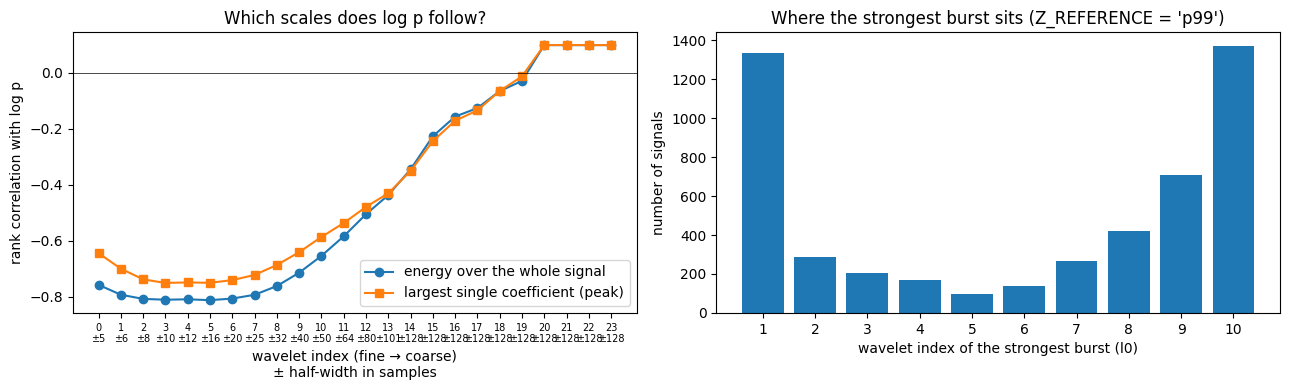

In [48]:
# Rank correlations do not depend on how each scale is normalized, so no choice is hidden here.
X_all = coeff_modulus(x1, fQ[:, :-1])                                 # (n, 24, M), all band-pass wavelets
energy_l = (X_all.astype(np.float64) ** 2).mean(2)                    # (n, 24): spread-out activity
peak_l = X_all.max(2)                                                 # (n, 24): strongest single coefficient
rho_energy = [stats.spearmanr(energy_l[:, l], logp)[0] for l in range(X_all.shape[1])]
rho_peak = [stats.spearmanr(peak_l[:, l], logp)[0] for l in range(X_all.shape[1])]
del X_all

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
xs = np.arange(len(w_all))
ax1.plot(xs, rho_energy, 'o-', label='energy over the whole signal')
ax1.plot(xs, rho_peak, 's-', label='largest single coefficient (peak)')
ax1.axhline(0, color='k', lw=0.5)
ax1.set_xticks(xs); ax1.set_xticklabels([f'{l}\n±{wl}' for l, wl in zip(xs, w_all)], fontsize=7)
ax1.set_xlabel('wavelet index (fine → coarse)\n± half-width in samples')
ax1.set_ylabel('rank correlation with log p'); ax1.legend(); ax1.set_title('Which scales does log p follow?')
counts = desc.l0.value_counts().reindex(band_idx, fill_value=0)
ax2.bar(np.arange(len(band_idx)), counts.to_numpy())
ax2.set_xticks(np.arange(len(band_idx))); ax2.set_xticklabels(band_idx)
ax2.set_xlabel('wavelet index of the strongest burst (l0)'); ax2.set_ylabel('number of signals')
ax2.set_title(f'Where the strongest burst sits (Z_REFERENCE = {Z_REFERENCE!r})')
fig.tight_layout(); plt.show()

In [49]:
# Can log p be predicted from the energy at each scale alone? Fit on half the signals, test on the other half.
Xe = np.log(energy_l[:, :20])                 # wavelets 20-23 sit on the same single frequency (near-copies): dropped
Xe = np.column_stack([np.ones(len(Xe)), Xe])
idx = np.random.default_rng(RNG_SEED).permutation(len(logp)); tr, te = idx[: len(idx) // 2], idx[len(idx) // 2:]
coef, *_ = np.linalg.lstsq(Xe[tr], logp[tr], rcond=None)
r2 = 1 - np.var(logp[te] - Xe[te] @ coef) / np.var(logp[te])
print(f'log p predicted from the energy at each of 20 scales: R^2 on signals not used in the fit = {r2:.3f}')

log p predicted from the energy at each of 20 scales: R^2 on signals not used in the fit = 0.711


## 2. Look at examples

There are four rows of 8 signals:
1. **strong and localized burst**: large $C_0$, large $\eta$;
2. **strong but spread out**: large $C_0$, small $\eta$;
3. **the biggest jumps**, i.e. the old criterion;
4. **ordinary signals** for comparison.

The red line marks where the burst is ($t_0$) and the orange band is one wavelet width around it. Each title gives $C_0$, $\eta$, the scale $l_0$ and $\log p$.

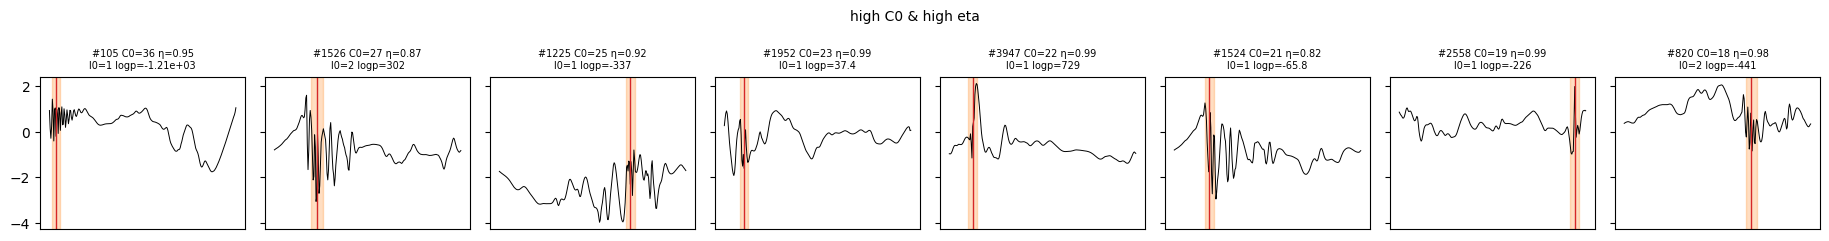

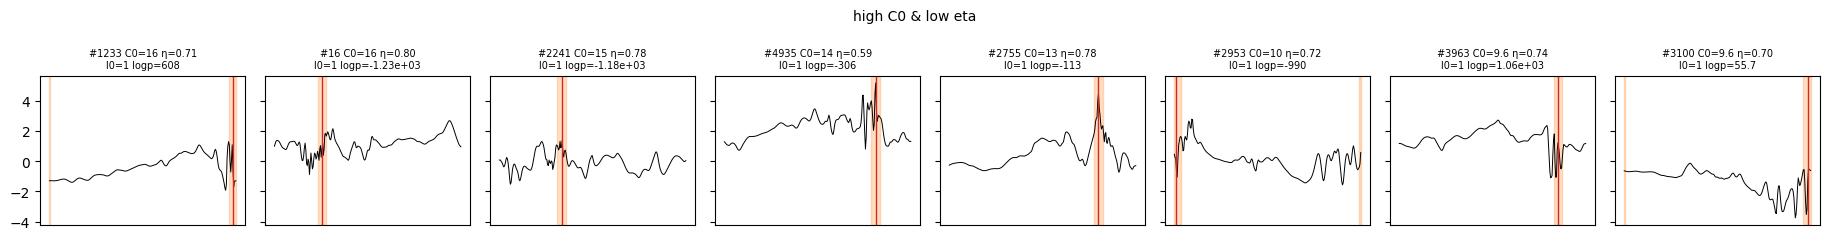

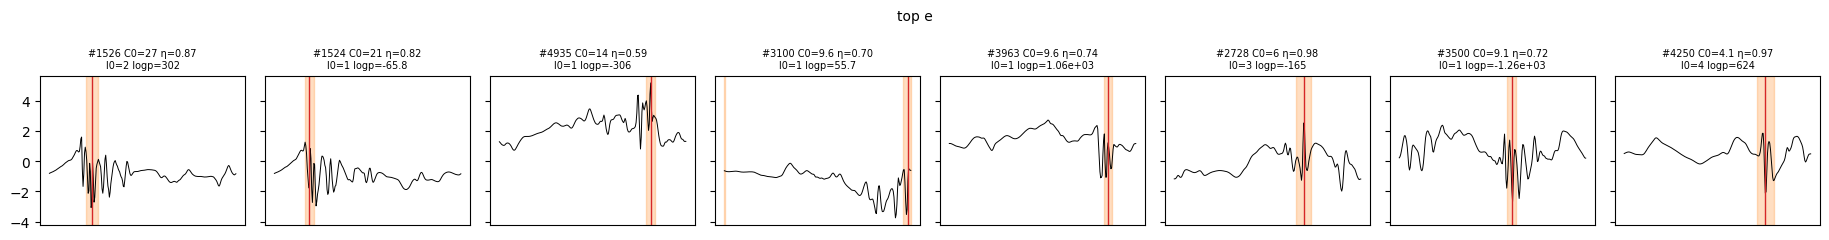

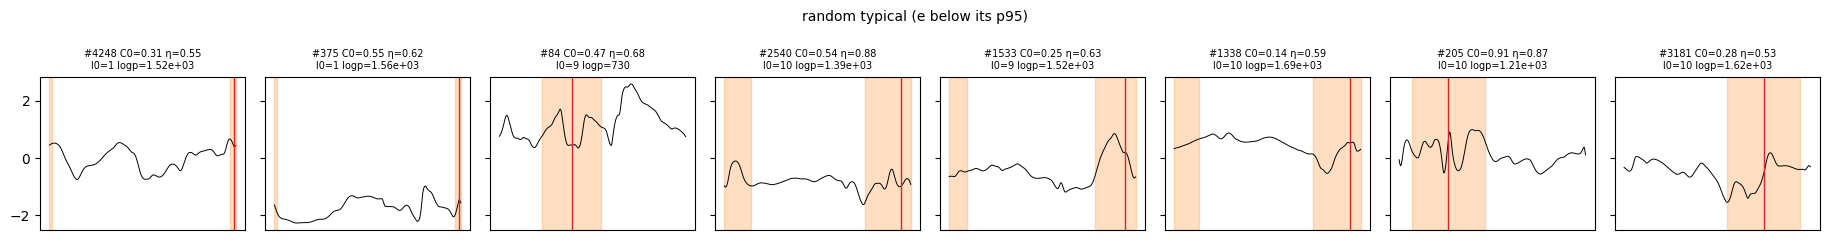

In [35]:
def pick_grids(desc, n=N_GRID, seed=RNG_SEED):
    r = np.random.default_rng(seed)
    hiC = desc.C0 >= desc.C0.quantile(1 - RARITIES[0])
    med = desc.eta.median()
    return {
        'high C0 & high eta': desc[hiC & (desc.eta >= med)].nlargest(n, 'C0').index,
        'high C0 & low eta': desc[hiC & (desc.eta < med)].nlargest(n, 'C0').index,
        'top e': desc.nlargest(n, 'e').index,
        'random typical (e below its p95)': r.choice(desc.index[desc.e < desc.e.quantile(0.95)], n, replace=False),
    }

def plot_grid(title, idx):
    if len(idx) == 0:
        print(f'{title}: no signal in this category'); return
    fig, axes = plt.subplots(1, len(idx), figsize=(2.3 * len(idx), 2.4), sharey=True, squeeze=False)
    for ax, i in zip(axes[0], idx):
        r = desc.loc[i]; t0 = int(r.t0); wl = int(w[list(band_idx).index(int(r.l0))])
        ax.plot(x1[i, 0].cpu().numpy(), 'k', lw=0.7)
        a, b = t0 - wl, t0 + wl                                        # atom window, wrapped (x is periodic)
        spans = [(0, b), (a + M, M - 1)] if a < 0 else [(a, M - 1), (0, b - M)] if b >= M else [(a, b)]
        for s0, s1 in spans:
            ax.axvspan(s0, s1, color='tab:orange', alpha=0.25)
        ax.axvline(t0, color='tab:red', lw=1)
        ax.set_title(f'#{i} C0={r.C0:.2g} η={r.eta:.2f}\nl0={int(r.l0)} logp={r.logp:.3g}', fontsize=7)
        ax.set_xticks([])
    fig.suptitle(title, fontsize=10); fig.tight_layout(); plt.show()

for title, idx in pick_grids(desc).items():
    plot_grid(title, idx)

## 3. Which definition of "extreme" better finds the signals the model finds unlikely?

We mark the top 5% (and the top 1%) of signals in two ways, **without looking at log p**:
* **e-label**: the biggest jumps (old criterion);
* **struct-label**: the strongest bursts ($C_0$), keeping only signals whose burst is localized ($\eta$ above its median).

Both labels mark the same number of signals.

For each label we compute the **AUC**: the probability that a marked signal is *more* likely than a random unmarked one.
* AUC = 0.5: the label says nothing about $\log p$.
* AUC close to 0: marked signals are almost always *less* likely.

So the better definition is the one with AUC **farther from 0.5**. `CI_lo`, `CI_hi` give the 95% uncertainty range, obtained by resampling the signals. `overlap_with_other` counts the signals that carry both labels.

In [36]:
def make_labels(desc, q):
    """Labels from descriptors only. Both have exactly k = round(q n) members (ASSUMPTION: equal sizes)."""
    k = int(round(q * len(desc)))
    lab_e = np.zeros(len(desc), bool); lab_e[np.argsort(-desc.e.to_numpy())[:k]] = True
    elig = np.flatnonzero(desc.eta.to_numpy() >= desc.eta.quantile(ETA_QUANTILE))
    lab_s = np.zeros(len(desc), bool); lab_s[elig[np.argsort(-desc.C0.to_numpy()[elig])[:k]]] = True
    return {'e-label': lab_e, 'struct-label': lab_s}

def auc(y, lab):
    """P(log p(label) > log p(rest)), ties counted 1/2 (Mann-Whitney U / (n1 n0))."""
    r = stats.rankdata(y); n1, n0 = lab.sum(), (~lab).sum()
    return (r[lab].sum() - n1 * (n1 + 1) / 2) / (n1 * n0)

def auc_boot(y, lab, n_boot=N_BOOT, seed=RNG_SEED):
    """Bootstrap over signals; each signal keeps its label (labels not recomputed: ASSUMPTION)."""
    r = np.random.default_rng(seed); n = len(y)
    draws = (r.integers(0, n, n) for _ in range(n_boot))
    b = [auc(y[s], lab[s]) for s in draws if 0 < lab[s].sum() < n]    # skip draws with an empty class
    return np.percentile(b, [2.5, 97.5])

labels = {q: make_labels(desc, q) for q in RARITIES}
rows = []
for q, labs in labels.items():
    for name, lab in labs.items():
        lo, hi = auc_boot(logp, lab)
        rows.append(dict(rarity=q, label=name, n=int(lab.sum()), AUC=auc(logp, lab), CI_lo=lo, CI_hi=hi,
                         overlap_with_other=int((lab & labs['e-label' if name == 'struct-label' else 'struct-label']).sum())))
auc_df = pd.DataFrame(rows)
display(auc_df)
# AUC < 0.5 means labelled signals are LESS likely. "Explains better" = farther from 0.5 (see H3 below).

,rarity,label,n,AUC,CI_lo,CI_hi,overlap_with_other
0,0.05,e-label,250,0.155,0.135,0.176,144
1,0.05,struct-label,250,0.182,0.16,0.205,144
2,0.01,e-label,50,0.168,0.122,0.218,21
3,0.01,struct-label,50,0.151,0.113,0.193,21


## 4. What sets log p: the strength of the burst or how localized it is?

We fit a straight line:
$$\log p \approx a\cdot \log C_0 + b\cdot \eta + \text{(one constant per scale } l_0\text{)}.$$
Everything is standardized (mean 0, standard deviation 1), so $a$ and $b$ can be compared directly. $b = 0.3$ means one standard deviation more of $\eta$ shifts $\log p$ by 0.3 standard deviations. `SE` is the uncertainty on each coefficient.

Below that is the rank correlation (Spearman, from −1 to 1) between $\log p$ and every quantity. It measures whether one tends to go up when the other does, whatever the shape of the relation.

In [37]:
def ols_standardized(desc):
    """z(log p) ~ a z(log C0) + b z(eta) + dummies(l0) (first l0 level dropped). Returns coef, SE for a, b."""
    zs = lambda v: (v - v.mean()) / v.std(ddof=1)
    D = pd.get_dummies(desc.l0, prefix='l0', drop_first=True, dtype=float)
    X = np.column_stack([np.ones(len(desc)), zs(np.log(desc.C0)), zs(desc.eta), D.to_numpy()])
    y = zs(desc.logp).to_numpy()
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    resid = y - X @ beta
    s2 = resid @ resid / (len(y) - X.shape[1])
    se = np.sqrt(np.diag(s2 * np.linalg.pinv(X.T @ X)))
    return pd.DataFrame({'coef': beta[1:3], 'SE': se[1:3]}, index=['a (log C0)', 'b (eta)']), 1 - resid.var() / y.var()

ols, r2 = ols_standardized(desc)
display(ols); print(f'R^2 (with l0 dummies) = {r2:.3g}')
spear = pd.Series({c: stats.spearmanr(desc[c], desc.logp)[0] for c in ['C0', 'eta', 'B', 'e', 'PR_W', 'PR_F', 'A']},
                  name='Spearman rho with log p')
display(spear.to_frame())

,coef,SE
a (log C0),-0.861,0.0108
b (eta),0.407,0.00988


R^2 (with l0 dummies) = 0.632


,Spearman rho with log p
C0,-0.731
eta,0.0268
B,-0.886
e,-0.723
PR_W,-0.61
PR_F,-0.684
A,-0.664


Each point is a signal, at (burst strength, localization), coloured by $\log p$. If localization matters, the colour should change mostly from bottom to top. If strength matters, it should change from left to right.

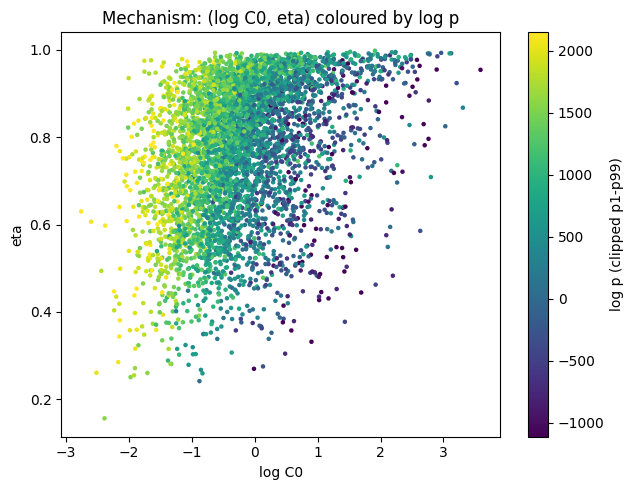

In [38]:
fig, ax = plt.subplots(figsize=(6.5, 5))
lo_c, hi_c = np.percentile(desc.logp, [1, 99])          # colour range clipped to p1-p99 (outliers)
sc = ax.scatter(np.log(desc.C0), desc.eta, c=desc.logp, s=5, cmap='viridis', vmin=lo_c, vmax=hi_c)
fig.colorbar(sc, label='log p (clipped p1-p99)')
ax.set_xlabel('log C0'); ax.set_ylabel('eta'); ax.set_title('Mechanism: (log C0, eta) coloured by log p')
fig.tight_layout(); plt.show()

## 5. Do bursts sit on a quiet background?

These are histograms of the background $B$ for the struct-labelled signals and for all the others. A small Mann–Whitney p-value with a lower median means the labelled events really sit on a quieter background.

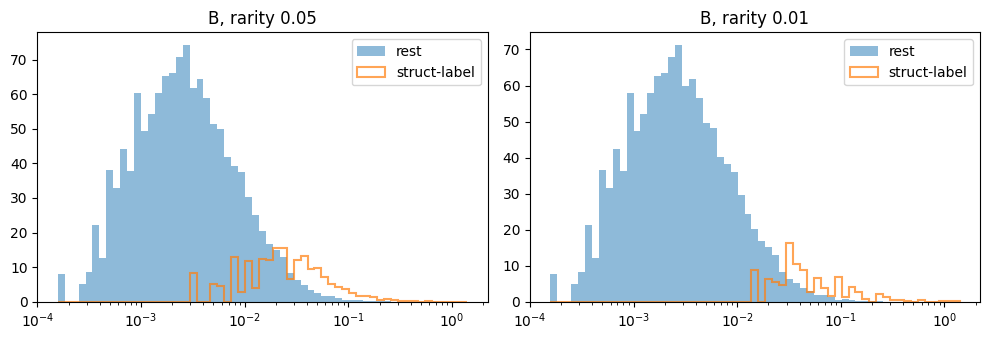

Spearman(B, log p) = -0.886
rarity 0.05: median B struct-label = 0.0521, rest = 0.0104, Mann-Whitney (less) p = 1
rarity 0.01: median B struct-label = 0.0991, rest = 0.011, Mann-Whitney (less) p = 1


In [39]:
fig, axes = plt.subplots(1, len(RARITIES), figsize=(5 * len(RARITIES), 3.5), squeeze=False)
bins = np.logspace(np.log10(desc.B.min()), np.log10(desc.B.max()), 60)
B_test = {}
for ax, q in zip(axes[0], RARITIES):
    lab = labels[q]['struct-label']
    ax.hist(desc.B[~lab], bins=bins, density=True, alpha=0.5, label='rest')
    ax.hist(desc.B[lab], bins=bins, density=True, alpha=0.7, histtype='step', lw=1.5, label='struct-label')
    ax.set_xscale('log'); ax.set_title(f'B, rarity {q:g}'); ax.legend()
    B_test[q] = (desc.B[lab].median(), desc.B[~lab].median(),
                 stats.mannwhitneyu(desc.B[lab], desc.B[~lab], alternative='less').pvalue)
fig.tight_layout(); plt.show()
rho_B = stats.spearmanr(desc.B, desc.logp)[0]
print(f'Spearman(B, log p) = {rho_B:.3g}')
for q, (mb, mr, p) in B_test.items():
    print(f'rarity {q:g}: median B struct-label = {mb:.3g}, rest = {mr:.3g}, Mann-Whitney (less) p = {p:.2g}')

## 6. Summary: one line per hypothesis

* **H2.** Localization matters more than strength: $b > 0$ and $|a| < |b|$.
* **H3.** The burst definition finds unlikely signals better than the jump definition. `holds` is the test exactly as written (AUC_struct > AUC_e). `holds_as_separation` asks which AUC is farther from 0.5; that is the meaningful version if events are *less* likely, because then both AUCs are below 0.5.
* **H4.** Events have a quieter background than other signals.
* **Control.** Wavelet sparsity follows $\log p$ more closely than Fourier sparsity.

`holds` is just True/False on one run; always read the numbers in `value` too.

In [40]:
a, b = ols.loc['a (log C0)', 'coef'], ols.loc['b (eta)', 'coef']
summary = [dict(hypothesis='H2: b > 0 and |a| small', value=f'a={a:.3g}, b={b:.3g}',
                holds=bool(b > 0 and abs(a) < abs(b)))]     # ASSUMPTION: "|a| small" read as |a| < |b|
for q in RARITIES:
    s = auc_df[(auc_df.rarity == q) & (auc_df.label == 'struct-label')].iloc[0]
    e_ = auc_df[(auc_df.rarity == q) & (auc_df.label == 'e-label')].iloc[0]
    # literal: AUC_struct > AUC_e with disjoint CIs; separation: |AUC - 0.5| larger with disjoint CIs
    summary.append(dict(hypothesis=f'H3 (rarity {q:g}): AUC_struct > AUC_e',
                        value=f'struct {s.AUC:.3f} [{s.CI_lo:.3f},{s.CI_hi:.3f}] vs e {e_.AUC:.3f} [{e_.CI_lo:.3f},{e_.CI_hi:.3f}]',
                        holds=bool(s.CI_lo > e_.CI_hi),
                        holds_as_separation=bool(abs(s.AUC - .5) > abs(e_.AUC - .5)
                                                 and (s.CI_hi < e_.CI_lo if s.AUC < .5 else s.CI_lo > e_.CI_hi))))
for q, (mb, mr, p) in B_test.items():
    summary.append(dict(hypothesis=f'H4 (rarity {q:g}): B lower for events', value=f'{mb:.3g} vs {mr:.3g}, p={p:.2g}',
                        holds=bool(mb < mr and p < 0.05)))
summary.append(dict(hypothesis='control: |rho(PR_W)| > |rho(PR_F)|', value=f"{spear['PR_W']:.3g} vs {spear['PR_F']:.3g}",
                    holds=bool(abs(spear['PR_W']) > abs(spear['PR_F']))))
display(pd.DataFrame(summary))

,hypothesis,value,holds,holds_as_separation
0,H2: b > 0 and |a| small,"a=-0.861, b=0.407",False,NaN
1,H3 (rarity 0.05): AUC_struct > AUC_e,"struct 0.182 [0.160,0.205] vs e 0.155 [0.135,0...",False,False
2,H3 (rarity 0.01): AUC_struct > AUC_e,"struct 0.151 [0.113,0.193] vs e 0.168 [0.122,0...",False,False
3,H4 (rarity 0.05): B lower for events,"0.0521 vs 0.0104, p=1",False,NaN
4,H4 (rarity 0.01): B lower for events,"0.0991 vs 0.011, p=1",False,NaN
5,control: |rho(PR_W)| > |rho(PR_F)|,-0.61 vs -0.684,False,NaN


In [51]:
# ---- settings for this cell ----
SPLICE_LABEL, SPLICE_RARITY = 'struct-label', 0.05   # which rare signals to dissect (label and rarity from section 3)
WINDOW_FACTOR = 1.0      # burst window = t0 ± WINDOW_FACTOR × (half-width of the wavelet at the burst's scale)
TAPER = 4                # samples of smooth cross-fade at each window edge, so the splice does not create a jump
DONOR_BAND = (40, 60)    # donors = ordinary signals, log p between these percentiles, in neither label

def logp_of(x):
    """log p (same theta, same potentials, same constant as above) of signals x (n, 1, M)."""
    out = []
    with torch.no_grad():
        for i in range(0, len(x), PHI_CHUNK):
            xc = x[i:i + PHI_CHUNK].to(device)
            out.append(torch.cat([p(xc).reshape(len(xc), -1) for p in pots.values()], 1).double().cpu().numpy())
    return np.concatenate(out) @ theta

def window_mask(center, half):
    """(n, 1, M) weights: 1 within ±half of center (periodic), smooth fall to 0 over TAPER samples, 0 elsewhere."""
    dt = np.abs(np.arange(M)[None, :] - center[:, None]); dt = np.minimum(dt, M - dt)
    m = 0.5 * (1 + np.cos(np.pi * np.clip(dt - half[:, None], 0, TAPER) / TAPER))
    return torch.tensor(m, dtype=x1.dtype)[:, None, :]

lab = labels[SPLICE_RARITY]
rare = np.flatnonzero(lab[SPLICE_LABEL])
lo, hi = np.percentile(logp, DONOR_BAND)
pool = np.flatnonzero((logp >= lo) & (logp <= hi) & ~lab['struct-label'] & ~lab['e-label'])
donor = np.random.default_rng(RNG_SEED).choice(pool, len(rare), replace=len(pool) < len(rare))
t0_r = desc.t0.to_numpy()[rare]
half = WINDOW_FACTOR * w[np.searchsorted(band_idx, desc.l0.to_numpy()[rare])]
assert (2 * half + 2 * TAPER < M / 2).all(), 'burst and control windows overlap: lower WINDOW_FACTOR'
m_burst, m_far = window_mask(t0_r, half), window_mask((t0_r + M // 2) % M, half)

xr, xd = x1[rare].cpu(), x1[donor].cpu()
versions = {
    'rare\n(original)': xr,
    'rare,\nburst replaced': xr * (1 - m_burst) + xd * m_burst,
    'rare, far window\nreplaced (control)': xr * (1 - m_far) + xd * m_far,
    'ordinary\n+ rare burst': xd * (1 - m_burst) + xr * m_burst,
    'ordinary\n(original)': xd,
}
lp = {k: logp_of(v) for k, v in versions.items()}
err = np.abs(lp['rare\n(original)'] - logp[rare]).max()
assert err < 1e-3 * logp.std(), f'recomputed log p differs from section 1 by {err:.3g}'

250 rare signals (struct-label, 0.05), each paired with one ordinary signal. Medians over pairs, in nats:
  rare signals are less likely than their ordinary partner by            860.5
  removing the burst makes the rare signal more likely by                 71.7   (8% of the gap)
  control: replacing an equally long window far from the burst         -431.9   (-50% of the gap)
  adding the burst makes the ordinary signal less likely by              540.4   (63% of the gap)
  (pairs where the rare signal is really less likely than its partner: 91%)


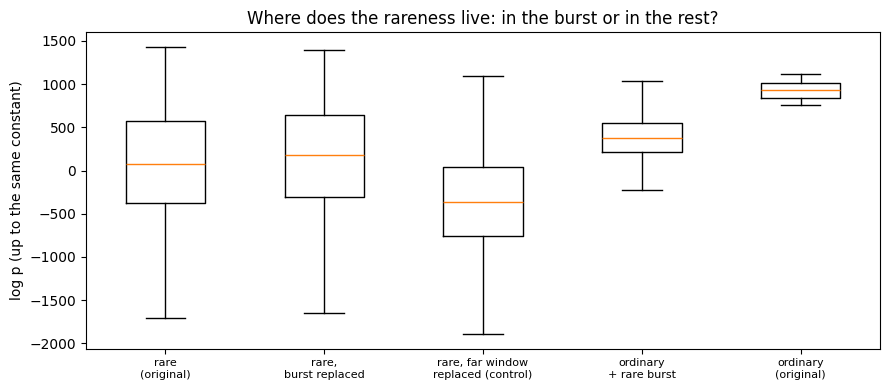

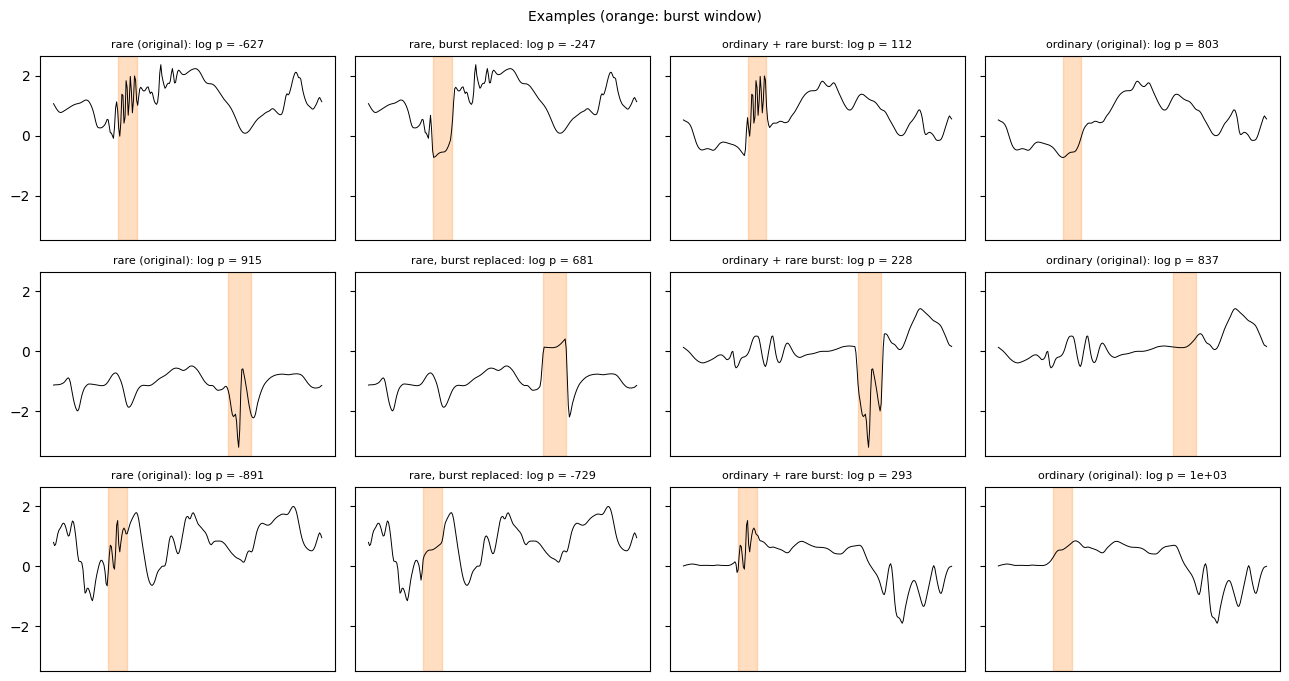

In [52]:
k_rare, k_noburst, k_ctrl, k_add, k_ord = versions
gap = np.median(lp[k_ord] - lp[k_rare])           # how much less likely the rare signals are, typical pair (nats)
d_remove = np.median(lp[k_noburst] - lp[k_rare])  # gained by removing the burst
d_ctrl = np.median(lp[k_ctrl] - lp[k_rare])       # gained by replacing an equally long window elsewhere
d_add = np.median(lp[k_ord] - lp[k_add])          # lost by adding the burst to an ordinary signal
print(f'{len(rare)} rare signals ({SPLICE_LABEL}, {SPLICE_RARITY:g}), each paired with one ordinary signal. Medians over pairs, in nats:')
print(f'  rare signals are less likely than their ordinary partner by        {gap:9.4g}')
print(f'  removing the burst makes the rare signal more likely by            {d_remove:9.4g}   ({100 * d_remove / gap:.0f}% of the gap)')
print(f'  control: replacing an equally long window far from the burst      {d_ctrl:9.4g}   ({100 * d_ctrl / gap:.0f}% of the gap)')
print(f'  adding the burst makes the ordinary signal less likely by          {d_add:9.4g}   ({100 * d_add / gap:.0f}% of the gap)')
print(f'  (pairs where the rare signal is really less likely than its partner: {100 * np.mean(lp[k_ord] > lp[k_rare]):.0f}%)')

fig, ax = plt.subplots(figsize=(9, 4))
ax.boxplot([lp[k] for k in versions], showfliers=False)
ax.set_xticks(range(1, len(versions) + 1)); ax.set_xticklabels(list(versions), fontsize=8)
ax.set_ylabel('log p (up to the same constant)'); ax.set_title('Where does the rareness live: in the burst or in the rest?')
fig.tight_layout(); plt.show()

n_show = 3
fig, axes = plt.subplots(n_show, 4, figsize=(13, 2.3 * n_show), sharey=True, squeeze=False)
for r in range(n_show):
    for c, k in enumerate([k_rare, k_noburst, k_add, k_ord]):
        ax = axes[r][c]
        ax.plot(versions[k][r, 0].numpy(), 'k', lw=0.7)
        ax.fill_between(np.arange(M), 0, 1, where=m_burst[r, 0].numpy() > 0.5, color='tab:orange', alpha=0.25,
                        transform=ax.get_xaxis_transform())
        ax.set_title(f"{k.replace(chr(10), ' ')}: log p = {lp[k][r]:.3g}", fontsize=8); ax.set_xticks([])
fig.suptitle('Examples (orange: burst window)', fontsize=10); fig.tight_layout(); plt.show()